<a href="https://colab.research.google.com/github/AidaSadeghi/Deep-Learning-with-pytorch/blob/main/Intermediate_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Advanced Architecture & Weight Dynamics
In deep networks, how you start is as important as how you finish. If weights are too small, signals vanish; if too large, they explode.

He (Kaiming) Initialization: Designed for layers followed by ReLU/ELU activations. It scales weights based on the number of input nodes to keep the variance of activations consistent.

Batch Normalization: This layer acts as a "check-and-balance" system. It normalizes the output of a previous layer by subtracting the batch mean and dividing by the batch standard deviation. This allows for higher learning rates and reduces sensitivity to initialization.

Vanishing Gradients: This occurs when gradients become so small during backpropagation that the early layers stop learning. Using ELU (Exponential Linear Unit) instead of ReLU helps because ELU can produce negative values, preventing neurons from "dying."

2. Optimization Strategy: Beyond SGD
Your notebooks transition from basic optimization to Adam. Understanding the difference is key for a portfolio:

Momentum: Like a ball rolling down a hill, momentum helps the optimizer accelerate through "flat" areas of the loss surface.

Adaptive Learning Rates (Adam): Adam calculates individual learning rates for different parameters. It keeps track of the "moving average" of gradients, making it robust for noisy data and complex architectures.

3. Transfer Learning & Model Surgery
When you don't have millions of data points, you use Fine-Tuning.

Freezing Layers: By setting requires_grad = False, you lock the "knowledge" of a pre-trained model (like one trained on millions of images).

The Head Swap: You typically remove the final layer (the "head") of a pre-trained model and replace it with a new layer specific to your data.


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ==========================================
# 1. GENERATING SYNTHETIC DATA
# ==========================================
def get_dummy_data():
    # 500 samples, 20 features
    X = torch.randn(500, 20)
    y = torch.randint(0, 2, (500, 1)).float()
    return DataLoader(TensorDataset(X, y), batch_size=32, shuffle=True)

# ==========================================
# 2. ADVANCED ARCHITECTURE
# ==========================================
class RobustNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Layer 1: Linear -> Batch Norm -> ELU
        self.fc1 = nn.Linear(20, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.elu = nn.ELU()

        # Layer 2: Hidden
        self.fc2 = nn.Linear(64, 32)

        # Output Layer
        self.out = nn.Linear(32, 1)

        # Applying He Initialization manually
        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity='leaky_relu')
        nn.init.kaiming_normal_(self.fc2.weight, nonlinearity='leaky_relu')

    def forward(self, x):
        x = self.elu(self.bn1(self.fc1(x)))
        x = self.elu(self.fc2(x))
        return torch.sigmoid(self.out(x))

# ==========================================
# 3. TRAINING WITH GRADIENT INSPECTION
# ==========================================
model = RobustNet()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()
train_loader = get_dummy_data()

print("--- Training Progress ---")
for epoch in range(3):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()

        # Portfolio Tip: Show you understand gradients by monitoring them
        if batch_idx == 0:
            grad_norm = model.fc1.weight.grad.norm().item()
            print(f"Epoch {epoch+1} | Loss: {loss.item():.4f} | Grad Norm: {grad_norm:.6f}")

        optimizer.step()

# ==========================================
# 4. MODEL SURGERY (Fine-Tuning Example)
# ==========================================
print("\n--- Performing Model Surgery ---")
# Freeze the first layer to preserve 'feature detection'
for param in model.fc1.parameters():
    param.requires_grad = False

# Replace the output layer for a new task (e.g., 5-class classification)
model.out = nn.Linear(32, 5)
print("Updated Model Head for 5-class classification:")
print(model.out)



--- Training Progress ---
Epoch 1 | Loss: 0.8308 | Grad Norm: 0.213330
Epoch 2 | Loss: 0.6892 | Grad Norm: 0.135740
Epoch 3 | Loss: 0.7098 | Grad Norm: 0.126649

--- Performing Model Surgery ---
Updated Model Head for 5-class classification:
Linear(in_features=32, out_features=5, bias=True)


In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for features, labels in dataloader:
            outputs = model(features)
            # Ensure predictions are binary (0 or 1)
            preds = (outputs > 0.5).float()

            # Move to CPU and convert to numpy
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    # CRITICAL FIX: Flatten the lists of arrays into a single 1D array
    # This converts [[0], [1]] into [0, 1]
    y_pred = np.concatenate(all_preds).ravel()
    y_true = np.concatenate(all_labels).ravel()

    # Ensure they are integers for the report
    y_pred = y_pred.astype(int)
    y_true = y_true.astype(int)

    print("--- Detailed Performance Metrics ---")
    print(classification_report(y_true, y_pred, target_names=['Class 0', 'Class 1']))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    cm

--- Detailed Performance Metrics ---
              precision    recall  f1-score   support

     Class 0       0.42      0.48      0.45       234
     Class 1       0.48      0.42      0.44       266

    accuracy                           0.45       500
   macro avg       0.45      0.45      0.45       500
weighted avg       0.45      0.45      0.45       500



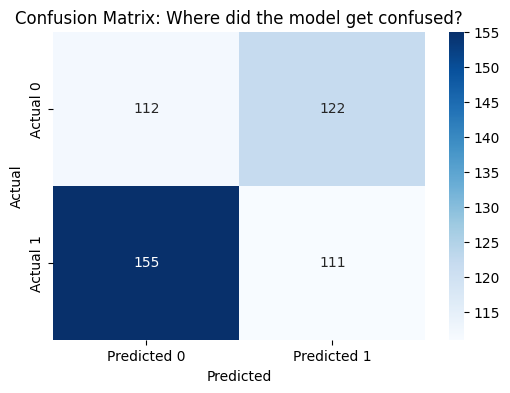

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for features, labels in dataloader:
            outputs = model(features)
            preds = (outputs > 0.5).float()

            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    # 1. Classification Report (Precision, Recall, F1)
    print("--- Detailed Performance Metrics ---")
    print(classification_report(all_labels, all_preds, target_names=['Class 0', 'Class 1']))

    # 2. Confusion Matrix Visualization
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: Where did the model get confused?')
    plt.show()


# If you defined your model like this:
model = RobustNet()

# Call the evaluation like this:
evaluate_model(model, train_loader)